In [1]:
import numpy as np
import random

In [2]:
# !pip install graphviz

In [6]:
from graphviz import Digraph

In [586]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [593]:
class Value:
  def __init__(self, data, children=(), op=''):
    # payload
    self.data = data
    # children and op used to obtain this value
    self._prev  = set(children)
    self._op = op

    #inital grad for a value = 0
    self.grad = 0
    self._backward = lambda : None

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    def backward():
      self.grad += out.grad
      other.grad += out.grad
    out._backward = backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = backward
    return out

  def __neg__(self):
    return self * -1

  def __sub__ (self, other):
    return self + (-other)

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def backward():
      self.grad += out.grad * (other * self.data ** (other -1))

    out._backward = backward
    return out

  def __truediv__(self, other):
    return self * other**-1

  def __rmul__(self, other):
    return self * other

  def __radd__(self, other):
    return self + other

  def __rsub__(self, other):
    return other + (-self)

  def __repr__(self):
    return f"Value(data={self.data}, grad={self.grad})"

  def __rtruediv__(self, other):
        return other * self**-1

  def exp(self):
    out  = Value(np.exp(self.data), (self,), 'exp')

    def backward():
      self.grad += out.data * out.grad

    out._backward = backward
    return out


  def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out


  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1
    for val in reversed(topo):
      val._backward()

def __repr__(self):
    return f"Value(data={self.data}, grad={self.grad})"



c = a ^ b

dc/da = b a ^ b-1

d = c + e

dd/da = grad.c + b .a ^ b-1

In [594]:
h = 0.001
a = Value(0.5)
b = Value(-2)
c = a + b
d = Value(3)
e = c * d
L1 = e.data

a = Value(0.5)
a+=h
b = Value(-2)
c = a + b
d = Value(3)
e = c * d

L2 = e.data

e.grad = 1

In [595]:
e.backward()

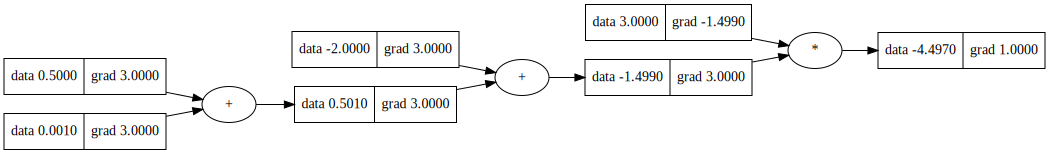

In [596]:
draw_dot(e)

In [597]:
(L2-L1)/h

3.0000000000001137

## Neural Network

In [598]:
import numpy as np
import random
from itertools import groupby

In [599]:
class Module():
  parameters = lambda self: []
  def zero_grad(self):
    for p in self.parameters():
      p.grad = 0

In [600]:
class Neuron(Module):

  def __init__(self, nin, nonlin=True) -> None:
     super().__init__()
     self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
     self.b = Value(random.uniform(-1,1))
     self.nonlin = nonlin

  def __call__(self, x):
    act = (sum((wi*xi for wi, xi in zip(self.w, x)), self.b))
    return act.relu() if self.nonlin else act

  def parameters(self):
    return self.w + [self.b]

  def __repr__(self):
    return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"


In [601]:
x = [2, 4, 5, 6]

neuron = Neuron(nin=4)
print(neuron)
neuron(x)

ReLUNeuron(4)


Value(data=0, grad=0)

In [602]:
class Layer(Module):
  def __init__(self, nin, nout,**kwargs) -> None:
    super().__init__()
    self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

  def __call__(self,x):
    out = [n(x) for n in self.neurons]
    return out[0] if len(out) == 1 else out

  def parameters(self):
    return [p for n in self.neurons for p in n.parameters()]

  def __repr__(self) -> str:
    result = []
    for key, group in groupby(self.neurons, key=str):
        count = sum(1 for _ in group)
        result.append(f"{count} x {key}" if count > 1 else key)
    return f"Layer({", ".join(result)})"

In [603]:
x = [1,2,3,4]
layer = Layer(nin=4, nout=3)
print(layer)
x = layer(x)
print(x)

Layer(3 x ReLUNeuron(4))
[Value(data=0, grad=0), Value(data=0, grad=0), Value(data=1.8511403381892606, grad=0)]


In [604]:
class MLP(Module):
  def __init__(self, nin, nouts) -> None:
    sz = [nin] + nouts
    self.layers = [Layer(nin=sz[i], nout=sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

  def __repr__(self):
    return f"MLP(\n{',\n'.join(str(layer) for layer in self.layers)}\n)"

In [605]:
mlp = MLP(4, [2, 1])
print(mlp)
x = [5,1,3,4]
y = 0.55533434

MLP(
Layer(2 x ReLUNeuron(4)),
Layer(LinearNeuron(2))
)


In [606]:
pred = mlp(x)
pred

Value(data=0.7529214863504863, grad=0)

In [607]:
mlp.parameters()

[Value(data=-0.6752868905745177, grad=0),
 Value(data=-0.07137941104636103, grad=0),
 Value(data=-0.5241100485605275, grad=0),
 Value(data=0.010487575202918986, grad=0),
 Value(data=0.7833028059346687, grad=0),
 Value(data=-0.8408229625487744, grad=0),
 Value(data=0.20872573271211414, grad=0),
 Value(data=-0.7334188666163401, grad=0),
 Value(data=0.8213250018521561, grad=0),
 Value(data=0.9302277412991327, grad=0),
 Value(data=0.6957306528956502, grad=0),
 Value(data=0.6698411571276621, grad=0),
 Value(data=0.7529214863504863, grad=0)]

In [608]:
rme = lambda pred, y : (pred - y) ** 2

rme_loss = rme(pred, y)
rme_loss


Value(data=0.03904068040292847, grad=0)

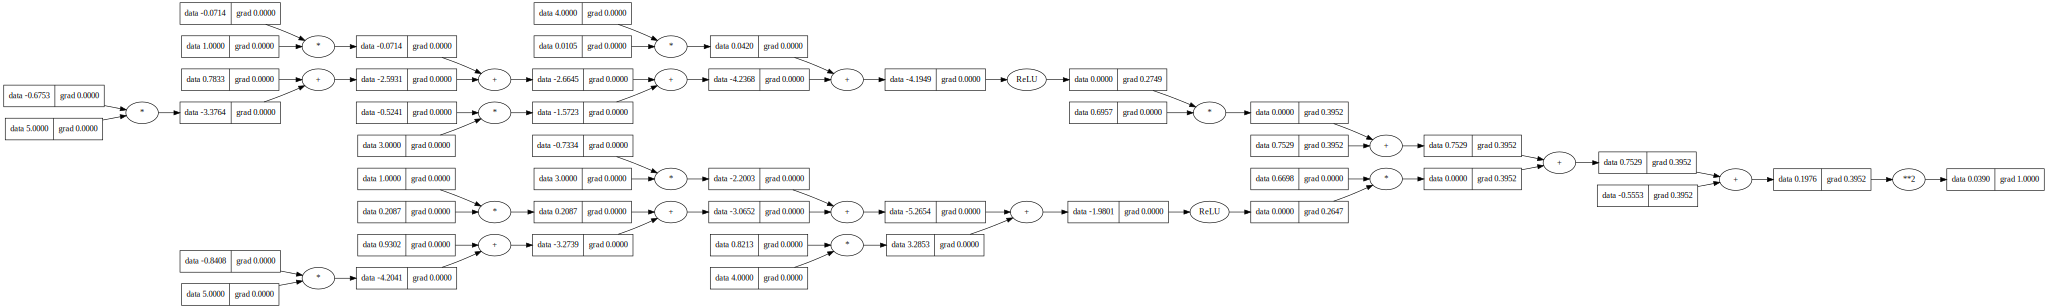

In [611]:
draw_dot(rme_loss)

In [610]:
rme_loss.backward()

##### Optimization

In [621]:
mlp = MLP(4, [2, 1])
print(mlp)
x = [2,1,-1,5]
y = -0.55533434

MLP(
Layer(2 x ReLUNeuron(4)),
Layer(LinearNeuron(2))
)


In [622]:
y_pred = mlp(x)
y_pred

Value(data=0.7060695266473825, grad=0)

In [647]:

for i in range(1000):

  y_pred  = mlp(x)
  loss = rme(y_pred, y)
  loss.backward()

  if i%50==0:
    print(f"epoch: {i}, loss: {loss.data}")
    learning_rate = 1.0e-3

    for p in mlp.parameters():
      p.data -= learning_rate * p.grad
    mlp.zero_grad()




epoch: 0, loss: 4.930380657631324e-32
epoch: 50, loss: 4.930380657631324e-32
epoch: 100, loss: 4.930380657631324e-32
epoch: 150, loss: 4.930380657631324e-32
epoch: 200, loss: 4.930380657631324e-32
epoch: 250, loss: 4.930380657631324e-32
epoch: 300, loss: 4.930380657631324e-32
epoch: 350, loss: 4.930380657631324e-32
epoch: 400, loss: 4.930380657631324e-32
epoch: 450, loss: 4.930380657631324e-32
epoch: 500, loss: 4.930380657631324e-32
epoch: 550, loss: 4.930380657631324e-32
epoch: 600, loss: 4.930380657631324e-32
epoch: 650, loss: 4.930380657631324e-32
epoch: 700, loss: 4.930380657631324e-32
epoch: 750, loss: 4.930380657631324e-32
epoch: 800, loss: 4.930380657631324e-32
epoch: 850, loss: 4.930380657631324e-32
epoch: 900, loss: 4.930380657631324e-32
epoch: 950, loss: 4.930380657631324e-32


In [643]:
y_pred

Value(data=-0.5553343399999997, grad=6.661338147750939e-16)